In [7]:
import warnings
warnings.filterwarnings(action='ignore') 

import datetime
import pandas as pd
import numpy as np
import csv
import folium
from folium.plugins import HeatMap 
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler 
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.cluster import KMeans    ##  K-means 임포트
from sklearn.metrics import silhouette_score
import scipy as sp
from scipy.cluster.hierarchy import dendrogram, linkage
import statsmodels.formula.api as smf
from dateutil.relativedelta import relativedelta
# import setuptools.dist
from yellowbrick.cluster import KElbowVisualizer
from mpl_toolkits.mplot3d import Axes3D
import networkx as nx
from wordcloud import WordCloud
import re
from collections import Counter
plt.rc('font',family='D2CodingLigature Nerd Font')
# plt.rcParams['axes.unicode_minus']=False  # '- 표시

### 대한민국헌법.txt _ 워드클라우드

In [4]:
# 1. 파일 읽기
txt = open('../../data/대한민국헌법.txt','rt', encoding='UTF-8').read()
txt

'\ufeff대한민국헌법\n[시행 1988. 2. 25] [헌법 제10호, 1987. 10. 29, 전부개정]\n\n유구한 역사와 전통에 빛나는 우리 대한국민은 3·1운동으로 건립된 대한민국임시정부의 법통과 불의에 항거한 4·19민주이념을 계승하고, 조국의 민주개혁과 평화적 통일의 사명에 입각하여 정의·인도와 동포애로써 민족의 단결을 공고히 하고, 모든 사회적 폐습과 불의를 타파하며, 자율과 조화를 바탕으로 자유민주적 기본질서를 더욱 확고히 하여 정치·경제·사회·문화의 모든 영역에 있어서 각인의 기회를 균등히 하고, 능력을 최고도로 발휘하게 하며, 자유와 권리에 따르는 책임과 의무를 완수하게 하여, 안으로는 국민생활의 균등한 향상을 기하고 밖으로는 항구적인 세계평화와 인류공영에 이바지함으로써 우리들과 우리들의 자손의 안전과 자유와 행복을 영원히 확보할 것을 다짐하면서 1948년 7월 12일에 제정되고 8차에 걸쳐 개정된 헌법을 이제 국회의 의결을 거쳐 국민투표에 의하여 개정한다. \n       제1장 총강 \n제1조 ①대한민국은 민주공화국이다.\n  ②대한민국의 주권은 국민에게 있고, 모든 권력은 국민으로부터 나온다.\n제2조 ①대한민국의 국민이 되는 요건은 법률로 정한다.\n  ②국가는 법률이 정하는 바에 의하여 재외국민을 보호할 의무를 진다.\n제3조 대한민국의 영토는 한반도와 그 부속도서로 한다.\n제4조 대한민국은 통일을 지향하며, 자유민주적 기본질서에 입각한 평화적 통일 정책을 수립하고 이를 추진한다.\n제5조 ①대한민국은 국제평화의 유지에 노력하고 침략적 전쟁을 부인한다.\n  ②국군은 국가의 안전보장과 국토방위의 신성한 의무를 수행함을 사명으로 하며, 그 정치적 중립성은 준수된다.\n제6조 ①헌법에 의하여 체결·공포된 조약과 일반적으로 승인된 국제법규는 국내법과 같은 효력을 가진다.\n  ②외국인은 국제법과 조약이 정하는 바에 의하여 그 지위가 보장된다.\n제7조 ①공무원은 국민전체에 대한 봉사자이며, 국민에 대하여 책임을 진다.\n  ②공무원의

In [5]:
# 2. 한글과 공백만 남기기 (특수문자 제거)
clean_txt = re.sub(r"[^가-힣\s]", " ", txt)
clean_txt

' 대한민국헌법\n 시행               헌법 제  호                전부개정 \n\n유구한 역사와 전통에 빛나는 우리 대한국민은    운동으로 건립된 대한민국임시정부의 법통과 불의에 항거한     민주이념을 계승하고  조국의 민주개혁과 평화적 통일의 사명에 입각하여 정의 인도와 동포애로써 민족의 단결을 공고히 하고  모든 사회적 폐습과 불의를 타파하며  자율과 조화를 바탕으로 자유민주적 기본질서를 더욱 확고히 하여 정치 경제 사회 문화의 모든 영역에 있어서 각인의 기회를 균등히 하고  능력을 최고도로 발휘하게 하며  자유와 권리에 따르는 책임과 의무를 완수하게 하여  안으로는 국민생활의 균등한 향상을 기하고 밖으로는 항구적인 세계평화와 인류공영에 이바지함으로써 우리들과 우리들의 자손의 안전과 자유와 행복을 영원히 확보할 것을 다짐하면서     년  월   일에 제정되고  차에 걸쳐 개정된 헌법을 이제 국회의 의결을 거쳐 국민투표에 의하여 개정한다  \n       제 장 총강 \n제 조  대한민국은 민주공화국이다 \n   대한민국의 주권은 국민에게 있고  모든 권력은 국민으로부터 나온다 \n제 조  대한민국의 국민이 되는 요건은 법률로 정한다 \n   국가는 법률이 정하는 바에 의하여 재외국민을 보호할 의무를 진다 \n제 조 대한민국의 영토는 한반도와 그 부속도서로 한다 \n제 조 대한민국은 통일을 지향하며  자유민주적 기본질서에 입각한 평화적 통일 정책을 수립하고 이를 추진한다 \n제 조  대한민국은 국제평화의 유지에 노력하고 침략적 전쟁을 부인한다 \n   국군은 국가의 안전보장과 국토방위의 신성한 의무를 수행함을 사명으로 하며  그 정치적 중립성은 준수된다 \n제 조  헌법에 의하여 체결 공포된 조약과 일반적으로 승인된 국제법규는 국내법과 같은 효력을 가진다 \n   외국인은 국제법과 조약이 정하는 바에 의하여 그 지위가 보장된다 \n제 조  공무원은 국민전체에 대한 봉사자이며  국민에 대하여 책임을 진다 \n   공무원의 신분과 

In [6]:
# 3. 단어 리스트 만들기 (공백 기준)
words = clean_txt.split()
words

['대한민국헌법',
 '시행',
 '헌법',
 '제',
 '호',
 '전부개정',
 '유구한',
 '역사와',
 '전통에',
 '빛나는',
 '우리',
 '대한국민은',
 '운동으로',
 '건립된',
 '대한민국임시정부의',
 '법통과',
 '불의에',
 '항거한',
 '민주이념을',
 '계승하고',
 '조국의',
 '민주개혁과',
 '평화적',
 '통일의',
 '사명에',
 '입각하여',
 '정의',
 '인도와',
 '동포애로써',
 '민족의',
 '단결을',
 '공고히',
 '하고',
 '모든',
 '사회적',
 '폐습과',
 '불의를',
 '타파하며',
 '자율과',
 '조화를',
 '바탕으로',
 '자유민주적',
 '기본질서를',
 '더욱',
 '확고히',
 '하여',
 '정치',
 '경제',
 '사회',
 '문화의',
 '모든',
 '영역에',
 '있어서',
 '각인의',
 '기회를',
 '균등히',
 '하고',
 '능력을',
 '최고도로',
 '발휘하게',
 '하며',
 '자유와',
 '권리에',
 '따르는',
 '책임과',
 '의무를',
 '완수하게',
 '하여',
 '안으로는',
 '국민생활의',
 '균등한',
 '향상을',
 '기하고',
 '밖으로는',
 '항구적인',
 '세계평화와',
 '인류공영에',
 '이바지함으로써',
 '우리들과',
 '우리들의',
 '자손의',
 '안전과',
 '자유와',
 '행복을',
 '영원히',
 '확보할',
 '것을',
 '다짐하면서',
 '년',
 '월',
 '일에',
 '제정되고',
 '차에',
 '걸쳐',
 '개정된',
 '헌법을',
 '이제',
 '국회의',
 '의결을',
 '거쳐',
 '국민투표에',
 '의하여',
 '개정한다',
 '제',
 '장',
 '총강',
 '제',
 '조',
 '대한민국은',
 '민주공화국이다',
 '대한민국의',
 '주권은',
 '국민에게',
 '있고',
 '모든',
 '권력은',
 '국민으로부터',
 '나온다',
 '제',
 '조',
 '대한민국의',
 '국민이',
 '되

In [9]:
words2 = [i   for i in words  if (len(i) >=2) & (len(i)<=6)  ]
words2

['대한민국헌법',
 '시행',
 '헌법',
 '전부개정',
 '유구한',
 '역사와',
 '전통에',
 '빛나는',
 '우리',
 '대한국민은',
 '운동으로',
 '건립된',
 '법통과',
 '불의에',
 '항거한',
 '민주이념을',
 '계승하고',
 '조국의',
 '민주개혁과',
 '평화적',
 '통일의',
 '사명에',
 '입각하여',
 '정의',
 '인도와',
 '동포애로써',
 '민족의',
 '단결을',
 '공고히',
 '하고',
 '모든',
 '사회적',
 '폐습과',
 '불의를',
 '타파하며',
 '자율과',
 '조화를',
 '바탕으로',
 '자유민주적',
 '기본질서를',
 '더욱',
 '확고히',
 '하여',
 '정치',
 '경제',
 '사회',
 '문화의',
 '모든',
 '영역에',
 '있어서',
 '각인의',
 '기회를',
 '균등히',
 '하고',
 '능력을',
 '최고도로',
 '발휘하게',
 '하며',
 '자유와',
 '권리에',
 '따르는',
 '책임과',
 '의무를',
 '완수하게',
 '하여',
 '안으로는',
 '국민생활의',
 '균등한',
 '향상을',
 '기하고',
 '밖으로는',
 '항구적인',
 '세계평화와',
 '인류공영에',
 '우리들과',
 '우리들의',
 '자손의',
 '안전과',
 '자유와',
 '행복을',
 '영원히',
 '확보할',
 '것을',
 '다짐하면서',
 '일에',
 '제정되고',
 '차에',
 '걸쳐',
 '개정된',
 '헌법을',
 '이제',
 '국회의',
 '의결을',
 '거쳐',
 '국민투표에',
 '의하여',
 '개정한다',
 '총강',
 '대한민국은',
 '대한민국의',
 '주권은',
 '국민에게',
 '있고',
 '모든',
 '권력은',
 '국민으로부터',
 '나온다',
 '대한민국의',
 '국민이',
 '되는',
 '요건은',
 '법률로',
 '정한다',
 '국가는',
 '법률이',
 '정하는',
 '바에',
 '의하여',
 '재외국민을',
 '보호할',
 '의무를',
 '진다'

In [11]:
# 4. 단어 빈도 계산
cnt = Counter(words2)
cnt

Counter({'또는': 70,
         '의하여': 66,
         '법률이': 58,
         '있다': 57,
         '한다': 56,
         '정하는': 50,
         '때에는': 42,
         '관한': 39,
         '모든': 37,
         '바에': 37,
         '국민은': 35,
         '법률로': 30,
         '정한다': 28,
         '국가는': 28,
         '대통령은': 28,
         '위하여': 26,
         '가진다': 25,
         '아니한다': 25,
         '국회의': 23,
         '필요한': 21,
         '없다': 21,
         '기타': 21,
         '대통령이': 19,
         '하며': 18,
         '헌법에': 17,
         '국가의': 16,
         '이를': 15,
         '사항은': 15,
         '국회는': 15,
         '의무를': 14,
         '항의': 14,
         '진다': 13,
         '이상의': 13,
         '임기는': 13,
         '대통령의': 13,
         '권리를': 12,
         '관하여': 12,
         '법률에': 11,
         '다만': 11,
         '대한': 10,
         '받지': 10,
         '의한': 10,
         '있어서': 9,
         '노력하여야': 9,
         '자유를': 9,
         '체포': 9,
         '있을': 9,
         '년으로': 9,
         '국회재적의원': 9,
         '과반수의': 9,
         '국무총리':

In [13]:
# 5. 워드클라우드 생성
wc = WordCloud(
    font_path='/home/erion/.local/share/fonts/d2codingligature-nerd-font/D2CodingLigatureNerdFont-Regular.ttf',  # 폰트 경로 필수!
    background_color='black',
    width=800,
    height=600,
    colormap='RdBu'
)

cloud = wc.generate_from_frequencies(cnt)

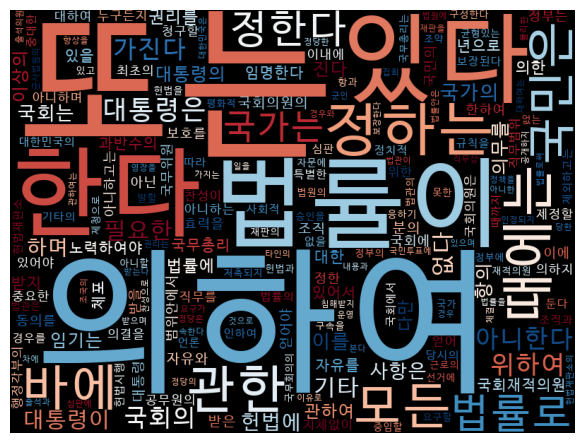

In [16]:
# 6. 시각화
plt.imshow(cloud.to_image())
plt.axis('off')
plt.savefig('../../data/wordcloud_002.png') 